## IMPORTS

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import pandas as pd
import os
import sys
import duckdb
from traj_ps.backends.bayes import BayesianTrajPS, BayesConfig
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve,
    precision_recall_curve, classification_report, confusion_matrix
)
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from scipy.stats import wilcoxon
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# Import shared notebook utilities
sys.path.insert(0, os.path.abspath('.'))
from notebook_utils import (
    aggregate_vitals_labs, drop_high_missing_columns, impute_features,
    plot_trajectory_distribution, plot_boxplots_with_stats, 
    plot_roc_pr_curves, print_statistical_comparisons
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✓ Imports successful")
print("✓ Shared utilities loaded")

✓ Imports successful


## LOAD

In [2]:
# Connect to MIMIC-III DuckDB
db_path = '../../data/mimic/mimiciii.duckdb'
conn = duckdb.connect(db_path, read_only=True)

print(f"✓ Connected to MIMIC-III database: {db_path}")

✓ Connected to MIMIC-III database: ../../data/mimic/mimiciii.duckdb


In [4]:
# Load ICU stays with sepsis criteria (Sepsis-3: suspected infection + SOFA ≥2)
# We'll identify sepsis patients using ICD-9 codes
hadm_query = """
WITH sepsis_patients AS (
    SELECT DISTINCT a.hadm_id
    FROM admissions a
    INNER JOIN diagnoses_icd d ON a.hadm_id = d.hadm_id
    WHERE 
        -- Sepsis ICD-9 codes
        (d.icd9_code LIKE '99591' OR  -- Sepsis
         d.icd9_code LIKE '99592' OR  -- Severe sepsis
         d.icd9_code LIKE '78552')    -- Septic shock
)
SELECT 
    a.subject_id::INTEGER AS subject_id,
    a.hadm_id::INTEGER AS hadm_id,
    a.admittime::TIMESTAMP as admittime,      -- Hospital admission time
    a.dischtime::TIMESTAMP as dischtime,      -- Hospital discharge time
    CAST(a.dischtime::DATE - a.admittime::DATE AS REAL) as los_days,  -- Hospital LOS
    p.gender,
    CAST((a.admittime::DATE - p.dob::DATE) / 365.25 AS INT) as age,
    a.hospital_expire_flag::INT as hospital_expire_flag,
    a.discharge_location
FROM admissions a
INNER JOIN patients p ON a.subject_id = p.subject_id
INNER JOIN sepsis_patients sp ON a.hadm_id = sp.hadm_id
WHERE 
    -- Filter adults
    CAST((a.admittime::DATE - p.dob::DATE) / 365.25 AS INT) BETWEEN 18 AND 90
    -- Minimum hospital stay
    AND CAST(a.dischtime::DATE - a.admittime::DATE AS REAL) >= 2.0
"""

hadm_df = conn.execute(hadm_query).fetchdf()
hadm_df.columns = hadm_df.columns.str.lower()
print(f"\n✓ Loaded {len(hadm_df):,} sepsis ICU admissions")
print(f"  Unique patients: {hadm_df['subject_id'].nunique():,}")
print(f"  Mean hospital LOS: {hadm_df['los_days'].mean():.1f} days")
print(f"  Mortality: {hadm_df['hospital_expire_flag'].mean():.1%}")


✓ Loaded 4,704 sepsis ICU admissions
  Unique patients: 4,131
  Mean hospital LOS: 16.2 days
  Mortality: 28.1%


In [5]:
# Sample subset for faster development 
hadm_subset = hadm_df.sort_values('admittime').drop_duplicates(subset=['subject_id'])['hadm_id'].sample(min(5000, hadm_df['subject_id'].nunique()), random_state=920).tolist()
hadm_df = hadm_df[hadm_df['hadm_id'].isin(hadm_subset)]

print(f"✓ Using {len(hadm_df):,} admissions for analysis")

✓ Using 4,131 admissions for analysis


In [6]:
# Load valid ranges from metadata
vital_meta = pd.read_csv('../../data/mimic/vital_metadata.csv')
labs_meta = pd.read_csv('../../data/mimic/labs_metadata.csv')

print("\n✓ Loaded metadata for value range validation")
print(f"   Vitals: {len(vital_meta)} item IDs")
print(f"   Labs: {len(labs_meta)} item IDs")


✓ Loaded metadata for value range validation
   Vitals: 43 item IDs
   Labs: 27 item IDs


In [7]:
vital_items = vital_meta['itemid'].to_list()
lab_items = labs_meta['itemid'].to_list()

In [8]:
vitals_query = """
SELECT chartevents.subject_id::INTEGER AS subject_id
    , chartevents.hadm_id::INTEGER AS hadm_id
    , chartevents.charttime::TIMESTAMP AS charttime
    , chartevents.itemid::INTEGER AS itemid
    , chartevents.valuenum::DOUBLE AS valuenum
      , admissions.admittime::TIMESTAMP AS admittime
        FROM chartevents
                 INNER JOIN admissions
                            ON chartevents.subject_id = admissions.subject_id
                                AND chartevents.hadm_id = admissions.hadm_id
                                AND chartevents.charttime::TIMESTAMP between
                                   (admissions.admittime::TIMESTAMP)
                                   AND (admissions.dischtime::TIMESTAMP)
                                AND itemid::INTEGER in {itemids}
                                AND chartevents.hadm_id::INTEGER in {hadm_ids}
      -- exclude rows marked as error
      AND chartevents.error::INTEGER IS DISTINCT FROM 1 
"""

vitals_df = conn.execute(vitals_query.format(itemids=vital_items, hadm_ids=hadm_subset)).fetchdf()
vitals_df.columns = vitals_df.columns.str.lower()
print(f"✓ Loaded vitals for {vitals_df['hadm_id'].nunique():,} hospital admissions")

✓ Loaded vitals for 4,103 hospital admissions


In [9]:
labs_query = """
SELECT labevents.subject_id::INTEGER AS subject_id
      , labevents.hadm_id::INTEGER AS hadm_id
      , labevents.charttime::TIMESTAMP AS charttime
      , labevents.itemid::INTEGER AS itemid
      , labevents.valuenum::DOUBLE AS valuenum
      , admissions.admittime::TIMESTAMP AS admittime
FROM labevents
          INNER JOIN admissions
                    ON labevents.subject_id = admissions.subject_id
                        AND labevents.hadm_id = admissions.hadm_id
                        AND labevents.charttime::TIMESTAMP between
                            (admissions.admittime::TIMESTAMP)
                            AND (admissions.dischtime::TIMESTAMP)
                        AND itemid::INTEGER IN {itemids}
                        AND labevents.hadm_id::INTEGER IN {hadm_ids}
"""

labs_df = conn.execute(labs_query.format(itemids=lab_items, hadm_ids=hadm_subset)).fetchdf()
labs_df.columns = labs_df.columns.str.lower()
print(f"✓ Loaded labs for {labs_df['hadm_id'].nunique():,} hospital admissions")

✓ Loaded labs for 4,125 hospital admissions


# PREPROCESS

In [10]:
# merge with metadata
vitals_df = vitals_df.merge(vital_meta, on='itemid', how='left')
labs_df = labs_df.merge(labs_meta, on='itemid', how='left')

# remove invalid values
vitals_df = vitals_df[vitals_df['valuenum'].between(vitals_df['min'], vitals_df['max'], inclusive='both')]
labs_df = labs_df[labs_df['valuenum'].between(labs_df['min'], labs_df['max'], inclusive='both')]

# convert fahrenheit to celsius
vitals_df.loc[vitals_df['units'] == 'F', 'valuenum'] = (vitals_df.loc[vitals_df['units'] == 'F', 'valuenum'] - 32) * 5.0/9.0
vitals_df.loc[vitals_df['units'] == 'F', 'units'] = 'C'
vitals_df.loc[vitals_df['feature name'] == 'TempF', 'feature name'] = 'TempC'

In [11]:
# Extract biomarkers for trajectory modeling
lactate_df = labs_df[labs_df['feature name'] == 'LACTATE'].copy()
lactate_df['time_days'] = (lactate_df['charttime'] - lactate_df['admittime']).dt.total_seconds() / 86400.0
lactate_df = lactate_df.rename(columns={'valuenum': 'lactate'})

wbc_df = labs_df[labs_df['feature name'] == 'WBC'].copy()
wbc_df['time_days'] = (wbc_df['charttime'] - wbc_df['admittime']).dt.total_seconds() / 86400.0
wbc_df = wbc_df.rename(columns={'valuenum': 'wbc'})

platelet_df = labs_df[labs_df['feature name'] == 'PLATELET'].copy()
platelet_df['time_days'] = (platelet_df['charttime'] - platelet_df['admittime']).dt.total_seconds() / 86400.0
platelet_df = platelet_df.rename(columns={'valuenum': 'platelet'})

print(f"\n✓ Extracted biomarker time series:")
print(f"  Lactate:  {len(lactate_df):,} measurements ({lactate_df['hadm_id'].nunique():,} admissions)")
print(f"  WBC:      {len(wbc_df):,} measurements ({wbc_df['hadm_id'].nunique():,} admissions)")
print(f"  Platelet: {len(platelet_df):,} measurements ({platelet_df['hadm_id'].nunique():,} admissions)")


✓ Extracted biomarker time series:
  Lactate:  40,488 measurements (3,698 admissions)
  WBC:      81,628 measurements (4,122 admissions)
  Platelet: 86,101 measurements (4,123 admissions)


In [ ]:
# Use shared utility function for standardized vitals/labs aggregation
vitals_agg, labs_agg = aggregate_vitals_labs(
    vitals_df=vitals_df,
    labs_df=labs_df,
    vital_meta=vital_meta,
    labs_meta=labs_meta
)

# Merge vitals and labs
vitals_labs_wide = vitals_agg.merge(labs_agg, on=['hadm_id', 'time_day'], how='outer')

print(f"\n✓ Processed vitals + labs with min/max/mean aggregation (using shared utilities):")
print(f"  Total daily observations: {len(vitals_labs_wide):,}")
print(f"  Total features: {len([c for c in vitals_labs_wide.columns if c not in ['hadm_id', 'time_day']])}")
print(f"  Example features: {list(vitals_labs_wide.columns[2:8])}")


✓ Processed vitals:
  Aggregated to 40,110 daily averages
  Features: ['dbp', 'Glucose', 'HeartRate', 'map', 'resp_rate', 'spo2', 'sbp', 'temperature', 'Weight']


In [ ]:
# Use shared utility function for dropping high-missing columns
vitals_labs_clean, dropped_cols = drop_high_missing_columns(
    df=vitals_labs_wide,
    threshold=0.2,
    exclude_cols=['hadm_id', 'time_day']
)

# Forward fill imputation with limits
vitals_labs_clean = vitals_labs_clean.set_index(['hadm_id', 'time_day']).sort_index()
vitals_labs_clean = vitals_labs_clean.groupby('hadm_id').ffill(limit=3)
vitals_labs_clean = vitals_labs_clean.reset_index()

print(f"\n✓ Imputation and cleanup (using shared utilities):")
print(f"  Dropped {len(dropped_cols)} high-missing columns (>20%)")
print(f"  Remaining features: {len([c for c in vitals_labs_clean.columns if c not in ['hadm_id', 'time_day']])}")
print(f"  Overall missing rate: {vitals_labs_clean.drop(columns=['hadm_id', 'time_day']).isna().mean().mean():.2%}")

# Store for later merging
vitals_labs_imputed = vitals_labs_clean


✓ Processed additional labs:
  Aggregated to 63,932 daily averages
  Features: ['bicarb', 'bilirubin', 'creatinine', 'inr']


In [14]:
# calculate baseline values (first 6 hours)
first_6h_lactate = lactate_df[lactate_df['charttime'] <= lactate_df['admittime'] + pd.Timedelta(hours=6)]
baseline_lactate = first_6h_lactate.sort_values('charttime').pivot_table(
    index='hadm_id',
    values='lactate',
    aggfunc='first'
).reset_index().rename(columns={'lactate': 'baseline_lactate'})

first_6h_wbc = wbc_df[wbc_df['charttime'] <= wbc_df['admittime'] + pd.Timedelta(hours=6)]
baseline_wbc = first_6h_wbc.sort_values('charttime').pivot_table(
    index='hadm_id',
    values='wbc',
    aggfunc='first'
).reset_index().rename(columns={'wbc': 'baseline_wbc'})

first_6h_platelet = platelet_df[platelet_df['charttime'] <= platelet_df['admittime'] + pd.Timedelta(hours=6)]
baseline_platelet = first_6h_platelet.sort_values('charttime').pivot_table(
    index='hadm_id',
    values='platelet',
    aggfunc='first'
).reset_index().rename(columns={'platelet': 'baseline_platelet'})

print(f"\n Baseline Lactate (first 6h):")
print(f"   Admissions with baseline: {len(baseline_lactate):,}")
print(f"   Mean: {baseline_lactate['baseline_lactate'].mean():.2f} mmol/L")
print(f"   Median: {baseline_lactate['baseline_lactate'].median():.2f} mmol/L")

print(f"\n Baseline WBC (first 6h):")
print(f"   Admissions: {len(baseline_wbc):,}")
print(f"   Mean: {baseline_wbc['baseline_wbc'].mean():.1f} K/μL")

print(f"\n Baseline Platelet (first 6h):")
print(f"   Admissions: {len(baseline_platelet):,}")
print(f"   Mean: {baseline_platelet['baseline_platelet'].mean():.0f} K/μL")


 Baseline Lactate (first 6h):
   Admissions with baseline: 1,980
   Mean: 2.57 mmol/L
   Median: 2.00 mmol/L

 Baseline WBC (first 6h):
   Admissions: 2,441
   Mean: 14.4 K/μL

 Baseline Platelet (first 6h):
   Admissions: 2,477
   Mean: 219 K/μL


In [15]:
# Filter admissions with sufficient measurements
lactate_counts = lactate_df.groupby('hadm_id').size()
wbc_counts = wbc_df.groupby('hadm_id').size()
platelet_counts = platelet_df.groupby('hadm_id').size()

# Require ≥3 measurements for at least lactate + one other marker
valid_lactate = lactate_counts[lactate_counts >= 3].index
valid_wbc = wbc_counts[wbc_counts >= 3].index
valid_platelet = platelet_counts[platelet_counts >= 3].index

# At least lactate + one other marker
valid_hadm_ids = valid_lactate[
    valid_lactate.isin(valid_wbc) | valid_lactate.isin(valid_platelet)
]

lactate_filtered = lactate_df[lactate_df['hadm_id'].isin(valid_hadm_ids)]
wbc_filtered = wbc_df[wbc_df['hadm_id'].isin(valid_hadm_ids)]
platelet_filtered = platelet_df[platelet_df['hadm_id'].isin(valid_hadm_ids)]

hadm_final = hadm_df[hadm_df['hadm_id'].isin(valid_hadm_ids)].merge(
    baseline_lactate, on='hadm_id', how='inner'
).merge(
    baseline_wbc, on='hadm_id', how='left'
).merge(
    baseline_platelet, on='hadm_id', how='left'
)

print(f"\nFiltering:")
print(f"   Admissions with ≥3 lactate + other markers: {len(hadm_final):,}")
print(f"   With WBC: {hadm_final['baseline_wbc'].notna().sum():,}")
print(f"   With platelets: {hadm_final['baseline_platelet'].notna().sum():,}")


Filtering:
   Admissions with ≥3 lactate + other markers: 1,559
   With WBC: 1,143
   With platelets: 1,155


In [16]:
# Create time series for all biomarkers
lactate_filtered['time_day'] = np.floor(lactate_filtered['time_days']).astype(int)
wbc_filtered['time_day'] = np.floor(wbc_filtered['time_days']).astype(int)
platelet_filtered['time_day'] = np.floor(platelet_filtered['time_days']).astype(int)

lactate_ts = lactate_filtered[['subject_id', 'hadm_id', 'time_days', 'time_day', 'lactate']].merge(
    hadm_final[['hadm_id', 'baseline_lactate', 'age', 'gender', 'hospital_expire_flag']].drop_duplicates(),
    on='hadm_id',
    how='left'
)

wbc_ts = wbc_filtered[['subject_id', 'hadm_id', 'time_days', 'time_day', 'wbc']].merge(
    hadm_final[['hadm_id', 'baseline_wbc']].drop_duplicates(),
    on='hadm_id',
    how='left'
)

platelet_ts = platelet_filtered[['subject_id', 'hadm_id', 'time_days', 'time_day', 'platelet']].merge(
    hadm_final[['hadm_id', 'baseline_platelet']].drop_duplicates(),
    on='hadm_id',
    how='left'
)

print(f"\nTime Series Created:")
print(f"   Lactate:  {len(lactate_ts):,} measurements")
print(f"   WBC:      {len(wbc_ts):,} measurements")
print(f"   Platelet: {len(platelet_ts):,} measurements")


Time Series Created:
   Lactate:  39,109 measurements
   WBC:      68,647 measurements
   Platelet: 72,805 measurements


In [54]:
# Save preprocessed data
os.makedirs('../../results/mimic/sepsis', exist_ok=True)
lactate_ts.to_csv('../../results/mimic/sepsis/lactate_timeseries.csv', index=False)
wbc_ts.to_csv('../../results/mimic/sepsis/wbc_timeseries.csv', index=False)
platelet_ts.to_csv('../../results/mimic/sepsis/platelet_timeseries.csv', index=False)
hadm_final.to_csv('../../results/mimic/sepsis/hadm_cohort.csv', index=False)

print(f"\n✓ Saved preprocessed data (3 biomarkers)")


✓ Saved preprocessed data (3 biomarkers)


## TRAJ PROBS

**Note**: Run `sepsis_trajs.py` script to compute trajectory probabilities using Bayesian modeling for **multiple biomarkers**:

**Lactate** (primary sepsis marker):
- `window=3.0 days`, `flat_thr=0.1`, `incline_thr=0.3`
- INCREASES = worsening

**WBC** (infection/inflammation):
- `window=3.0 days`, `flat_thr=1.0`, `incline_thr=3.0`
- Can increase (infection) or decrease (immunosuppression)

**Platelets** (organ dysfunction):
- `window=3.0 days`, `flat_thr=20`, `decline_thr=-50`
- DECREASES = worsening (thrombocytopenia)

In [ ]:
# Load trajectory probabilities for all biomarkers (after running sepsis_trajs.py)
lactate_traj = pd.read_csv('../../results/mimic/sepsis/lactate_trajectory_probs_bayes.csv')
wbc_traj = pd.read_csv('../../results/mimic/sepsis/wbc_trajectory_probs_bayes.csv')
platelet_traj = pd.read_csv('../../results/mimic/sepsis/platelet_trajectory_probs_bayes.csv')

print(f"✓ Loaded trajectory probabilities:")
print(f"   Lactate:  {len(lactate_traj):,} timepoints")
print(f"   WBC:      {len(wbc_traj):,} timepoints")
print(f"   Platelet: {len(platelet_traj):,} timepoints")

# Merge all trajectories on a common timepoint grid
# Use lactate as base (primary marker)
trajectory_probs = lactate_traj[['hadm_id', 'time_day', 'subject_id', 'lactate', 'baseline_lactate',
                                   'prob_stable', 'prob_gradual_increase', 'prob_rapid_increase']].rename(
    columns={
        'prob_stable': 'lactate_stable',
        'prob_gradual_increase': 'lactate_gradual_increase',
        'prob_rapid_increase': 'lactate_rapid_increase'
    }
)

# Add WBC trajectories
trajectory_probs = trajectory_probs.merge(
    wbc_traj[['hadm_id', 'time_day', 'wbc', 'baseline_wbc',
              'prob_stable', 'prob_gradual_increase', 'prob_rapid_increase']].rename(
        columns={
            'prob_stable': 'wbc_stable',
            'prob_gradual_increase': 'wbc_gradual_increase',
            'prob_rapid_increase': 'wbc_rapid_increase'
        }
    ),
    on=['hadm_id', 'time_day'],
    how='left'
)

# Add platelet trajectories
trajectory_probs = trajectory_probs.merge(
    platelet_traj[['hadm_id', 'time_day', 'platelet', 'baseline_platelet',
                   'prob_stable', 'prob_gradual_increase', 'prob_rapid_increase']].rename(
        columns={
            'prob_stable': 'platelet_stable',
            'prob_gradual_increase': 'platelet_gradual_decline',  # DECLINE for platelets
            'prob_rapid_increase': 'platelet_rapid_decline'
        }
    ),
    on=['hadm_id', 'time_day'],
    how='left'
)

# Add vitals and labs (now combined with min/max/mean aggregations)
trajectory_probs = trajectory_probs.merge(
    vitals_labs_imputed,
    on=['hadm_id', 'time_day'],
    how='left'
)

print(f"\n✓ Combined trajectory dataset: {len(trajectory_probs):,} timepoints")
print(f"   Total features: {len(trajectory_probs.columns)}")
print(f"   Trajectory coverage:\n {trajectory_probs[['lactate_stable', 'wbc_stable', 'platelet_stable']].isna().mean()}")

✓ Loaded trajectory probabilities:
   Lactate:  10,546 timepoints
   WBC:      12,172 timepoints
   Platelet: 14,099 timepoints

✓ Combined trajectory dataset: 10,546 timepoints
   Trajectory coverage:
 lactate_stable     0.000000
wbc_stable         0.488337
platelet_stable    0.461597
dtype: float64


In [ ]:
# Visualize trajectory type distributions (using shared utility)
# Determine dominant trajectory for each biomarker
trajectory_probs['dominant_lactate_traj'] = trajectory_probs[[
    'lactate_stable', 'lactate_gradual_increase', 'lactate_rapid_increase'
]].idxmax(axis=1).str.replace('lactate_', '')

trajectory_probs['dominant_wbc_traj'] = trajectory_probs[[
    'wbc_stable', 'wbc_gradual_increase', 'wbc_rapid_increase'
]].idxmax(axis=1).str.replace('wbc_', '')

trajectory_probs['dominant_platelet_traj'] = trajectory_probs[[
    'platelet_stable', 'platelet_gradual_decline', 'platelet_rapid_decline'
]].idxmax(axis=1).str.replace('platelet_', '')

# Visualize lactate trajectories
fig, axes = plot_trajectory_distribution(
    df=trajectory_probs.dropna(subset=['lactate']),
    traj_col='dominant_lactate_traj',
    biomarker_col='lactate',
    biomarker_name='Lactate'
)
plt.suptitle('Lactate Trajectory Distribution (Sepsis Cohort)', fontsize=16, fontweight='bold', y=1.02)
plt.savefig('../../results/mimic/sepsis/lactate_trajectory_distribution.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: lactate_trajectory_distribution.png")
plt.show()

# Visualize platelet trajectories
fig, axes = plot_trajectory_distribution(
    df=trajectory_probs.dropna(subset=['platelet']),
    traj_col='dominant_platelet_traj',
    biomarker_col='platelet',
    biomarker_name='Platelet Count'
)
plt.suptitle('Platelet Trajectory Distribution (Sepsis Cohort)', fontsize=16, fontweight='bold', y=1.02)
plt.savefig('../../results/mimic/sepsis/platelet_trajectory_distribution.png', dpi=300, bbox_inches='tight')
print("✓ Saved: platelet_trajectory_distribution.png")
plt.show()

## DEFINE OUTCOME

**Outcome**: Septic Shock (within 48h prediction window)
- Lactate ≥ 4 mmol/L AND vasopressor requirement
- OR 28-day mortality (severe outcome proxy)

In [28]:
# Detect vasopressor use
vasopressor_query = """
SELECT DISTINCT
    a.hadm_id::INT as hadm_id,
    MIN(EXTRACT(EPOCH FROM (ie.starttime::timestamp - a.admittime::timestamp)) / 86400) as vaso_start_day
FROM inputevents_mv ie
INNER JOIN admissions a ON ie.hadm_id = a.hadm_id
WHERE 
    ie.itemid IN (30047, 30120, 221906, 221289, 30044, 30119, 30309)  -- Vasopressors
    AND a.hadm_id::INT IN {hadm_ids}
GROUP BY a.hadm_id
"""

vasopressor_df = conn.execute(vasopressor_query.format(hadm_ids=tuple(hadm_final['hadm_id']))).fetchdf()
vasopressor_df.columns = vasopressor_df.columns.str.lower()
print(f"✓ Detected vasopressors in {len(vasopressor_df):,} admissions")

✓ Detected vasopressors in 551 admissions


In [29]:
trajectory_probs['hadm_id'] = trajectory_probs['hadm_id'].astype(hadm_final['hadm_id'].dtype)

In [34]:
hadm_df['hadm_id'].dtype

dtype('int32')

In [38]:
# Define septic shock outcome with prediction gap
PREDICTION_GAP_DAYS = 0.5   # 12 hours gap
PREDICTION_WINDOW_DAYS = 2.0  # 48 hours prediction window

print(f"Prediction Configuration:")
print(f"   Gap:    {PREDICTION_GAP_DAYS} days")
print(f"   Window: {PREDICTION_WINDOW_DAYS} days")
print(f"   Total:  {PREDICTION_GAP_DAYS + PREDICTION_WINDOW_DAYS} days lookahead")

septic_shock_events = []

for hadm_id, grp in trajectory_probs.groupby('hadm_id'):
    if hadm_id not in hadm_df['hadm_id'].values:
        continue
    grp = grp.sort_values('time_day')
    mortality = hadm_df[hadm_df['hadm_id'] == hadm_id]['hospital_expire_flag'].iloc[0]
    
    for i in range(len(grp)):
        current_time = grp.iloc[i]['time_day']
        current_lactate = grp.iloc[i]['lactate']
        
        # Skip if already in shock
        if current_lactate >= 4.0:
            continue
        
        # Define prediction window
        prediction_start = current_time + PREDICTION_GAP_DAYS
        prediction_end = current_time + PREDICTION_GAP_DAYS + PREDICTION_WINDOW_DAYS
        
        future_window = grp[
            (grp['time_day'] >= prediction_start) & 
            (grp['time_day'] <= prediction_end)
        ]
        
        if len(future_window) == 0:
            continue
        
        # Septic shock criteria
        high_lactate = (future_window['lactate'] >= 4.0).any()
        
        # Check vasopressor in window
        vasopressor_in_window = False
        if hadm_id in vasopressor_df['hadm_id'].values:
            vaso_start = vasopressor_df[vasopressor_df['hadm_id'] == hadm_id]['vaso_start_day'].iloc[0]
            vasopressor_in_window = (prediction_start <= vaso_start <= prediction_end)
        
        # Combined outcome: (high lactate + vasopressor) OR mortality
        target = int((high_lactate and vasopressor_in_window) or mortality)
        
        septic_shock_events.append({
            'hadm_id': hadm_id,
            'time_day': current_time,
            'target_septic_shock': target,
            'current_lactate': current_lactate
        })

outcome_df = pd.DataFrame(septic_shock_events)

# CRITICAL: For each patient, keep all negative windows but only the FIRST positive event
# This ensures we predict the first occurrence of septic shock
outcome_df = outcome_df.sort_values(['hadm_id', 'time_day'])
positive_first = outcome_df[outcome_df['target_septic_shock'] == 1].groupby('hadm_id').first().reset_index()
all_negatives = outcome_df[outcome_df['target_septic_shock'] == 0]
outcome_df = pd.concat([all_negatives, positive_first], ignore_index=True).sort_values(['hadm_id', 'time_day']).reset_index(drop=True)

print(f"\nOutcome Definition:")
print(f"   Total prediction windows: {len(outcome_df):,}")
print(f"   Unique patients: {outcome_df['hadm_id'].nunique():,}")
print(f"   Septic shock events (first per patient): {outcome_df['target_septic_shock'].sum():,}")
print(f"   Event rate: {outcome_df['target_septic_shock'].mean():.1%}")
print(f"   Avg windows/patient: {len(outcome_df) / outcome_df['hadm_id'].nunique():.1f}")


Prediction Configuration:
   Gap:    0.5 days
   Window: 2.0 days
   Total:  2.5 days lookahead

Outcome Definition:
   Total prediction windows: 4,408
   Unique patients: 1,606
   Septic shock events (first per patient): 628
   Event rate: 14.2%
   Avg windows/patient: 2.7


## FIT MODELS

Compare models with different feature sets:
1. Lactate Trajectory Only
2. Multi-Marker Trajectories (Lactate + WBC + Platelets)
3. Static Only (demographics + baseline values)
4. **Traj + Static + Dynamic** (comprehensive clinical model with vitals, labs, and organ dysfunction flags)

In [39]:
# Merge features and prepare dataset
prediction_dataset = outcome_df.merge(
    trajectory_probs[[
        'hadm_id', 'time_day',
        # Lactate trajectories
        'lactate_stable', 'lactate_gradual_increase', 'lactate_rapid_increase',
        # WBC trajectories
        'wbc_stable', 'wbc_gradual_increase', 'wbc_rapid_increase',
        # Platelet trajectories
        'platelet_stable', 'platelet_gradual_decline', 'platelet_rapid_decline',
        # Current trajectory marker values
        'lactate', 'wbc', 'platelet',
        # Vitals (dynamic)
        'HeartRate', 'sbp', 'dbp', 'map', 'temperature', 'resp_rate', 'spo2', 'Weight',
        # Additional labs (dynamic)
        'creatinine', 'bilirubin', 'inr', 'bicarb', 'Glucose'
    ]],
    on=['hadm_id', 'time_day'],
    how='left'
)

# Add static features
static_features = hadm_final[[
    'hadm_id', 'age', 'gender',
    'baseline_lactate', 'baseline_wbc', 'baseline_platelet'
]].drop_duplicates()
prediction_dataset = prediction_dataset.merge(static_features, on='hadm_id', how='left')

# Add derived features
prediction_dataset['lactate_worsening'] = (
    prediction_dataset['lactate_gradual_increase'] + 
    prediction_dataset['lactate_rapid_increase']
)
prediction_dataset['wbc_worsening'] = (
    prediction_dataset['wbc_gradual_increase'] + 
    prediction_dataset['wbc_rapid_increase']
)
prediction_dataset['platelet_worsening'] = (
    prediction_dataset['platelet_gradual_decline'] + 
    prediction_dataset['platelet_rapid_decline']
)

# Combined multi-marker worsening score
prediction_dataset['multi_marker_worsening'] = (
    prediction_dataset['lactate_worsening'].fillna(0) +
    prediction_dataset['wbc_worsening'].fillna(0) +
    prediction_dataset['platelet_worsening'].fillna(0)
) / 3

# Clinical flags
prediction_dataset['lactate_elevated'] = (prediction_dataset['current_lactate'] > 2.0).astype(int)
prediction_dataset['fever'] = (prediction_dataset['temperature'] > 100.4).astype(int)  # >38°C
prediction_dataset['hypothermia'] = (prediction_dataset['temperature'] < 96.8).astype(int)  # <36°C
prediction_dataset['tachycardia'] = (prediction_dataset['HeartRate'] > 90).astype(int)
prediction_dataset['tachypnea'] = (prediction_dataset['resp_rate'] > 20).astype(int)
prediction_dataset['hypotension'] = (prediction_dataset['map'] < 65).astype(int)
prediction_dataset['hypoxemia'] = (prediction_dataset['spo2'] < 90).astype(int)

# SOFA-like severity score components
prediction_dataset['aki_present'] = (prediction_dataset['creatinine'] > 1.2).astype(int)
prediction_dataset['coagulopathy'] = (prediction_dataset['inr'] > 1.5).astype(int)
prediction_dataset['liver_dysfunction'] = (prediction_dataset['bilirubin'] > 2.0).astype(int)

print(f"Prediction dataset: {len(prediction_dataset):,} windows")
print(f"Features with all 3 markers: {prediction_dataset[['lactate_worsening', 'wbc_worsening', 'platelet_worsening']].notna().all(axis=1).sum():,}")
print(f"Complete clinical data (traj+vitals+labs): {prediction_dataset[['lactate', 'HeartRate', 'map', 'creatinine']].notna().all(axis=1).sum():,}")

Prediction dataset: 4,408 windows
Features with all 3 markers: 2,081
Complete clinical data (traj+vitals+labs): 4,313


In [40]:
# Define feature sets
feature_sets = {
    'Lactate Trajectory Only': [
        'lactate_stable', 'lactate_gradual_increase', 'lactate_rapid_increase', 'lactate_worsening'
    ],
    'Multi-Marker Trajectories': [
        # Lactate
        'lactate_stable', 'lactate_gradual_increase', 'lactate_rapid_increase',
        # WBC
        'wbc_stable', 'wbc_gradual_increase', 'wbc_rapid_increase',
        # Platelet
        'platelet_stable', 'platelet_gradual_decline', 'platelet_rapid_decline',
        # Combined
        'multi_marker_worsening'
    ],
    'Static Only': [
        'age', 'gender', 'baseline_lactate', 'current_lactate', 'lactate_elevated'
    ],

    'Static + Dynamic': [
        # Static
        'age', 'gender', 'baseline_lactate',
        # Dynamic vitals
        'HeartRate', 'map', 'temperature', 'resp_rate', 'spo2',
        # Dynamic labs
        'lactate', 'wbc', 'platelet', 'creatinine', 'bilirubin', 'inr', 'Glucose',
        # Clinical flags
        'fever', 'hypothermia', 'tachycardia', 'tachypnea', 'hypotension', 'hypoxemia',
        'aki_present', 'coagulopathy', 'liver_dysfunction'
    ],
    'Traj + Static + Dynamic': [
        # Trajectories
        'lactate_stable', 'lactate_gradual_increase', 'lactate_rapid_increase',
        'wbc_stable', 'wbc_gradual_increase', 'wbc_rapid_increase',
        'platelet_stable', 'platelet_gradual_decline', 'platelet_rapid_decline',
        'multi_marker_worsening',
        # Static
        'age', 'gender', 'baseline_lactate',
        # Dynamic vitals
        'HeartRate', 'map', 'temperature', 'resp_rate', 'spo2',
        # Dynamic labs
        'lactate', 'wbc', 'platelet', 'creatinine', 'bilirubin', 'inr', 'Glucose',
        # Clinical flags
        'fever', 'hypothermia', 'tachycardia', 'tachypnea', 'hypotension', 'hypoxemia',
        'aki_present', 'coagulopathy', 'liver_dysfunction'
    ]
}

for name, features in feature_sets.items():
    print(f"{name:30s}: {len(features):2d} features")

Lactate Trajectory Only       :  4 features
Multi-Marker Trajectories     : 10 features
Static Only                   :  5 features
Static + Dynamic              : 24 features
Traj + Static + Dynamic       : 34 features


In [67]:
prediction_dataset.columns

Index(['hadm_id', 'time_day', 'target_septic_shock', 'current_lactate',
       'lactate_stable', 'lactate_gradual_increase', 'lactate_rapid_increase',
       'wbc_stable', 'wbc_gradual_increase', 'wbc_rapid_increase',
       'platelet_stable', 'platelet_gradual_decline', 'platelet_rapid_decline',
       'lactate', 'wbc', 'platelet', 'HeartRate', 'sbp', 'dbp', 'map',
       'temperature', 'resp_rate', 'spo2', 'Weight', 'creatinine', 'bilirubin',
       'inr', 'bicarb', 'Glucose', 'age', 'gender', 'baseline_lactate',
       'baseline_wbc', 'baseline_platelet', 'lactate_worsening',
       'wbc_worsening', 'platelet_worsening', 'multi_marker_worsening',
       'lactate_elevated', 'fever', 'hypothermia', 'tachycardia', 'tachypnea',
       'hypotension', 'hypoxemia', 'aki_present', 'coagulopathy',
       'liver_dysfunction'],
      dtype='object')

In [48]:
# Prepare data
all_features = list(set([f for features in feature_sets.values() for f in features]))

# Create prediction_clean by dropping only rows with missing target
prediction_clean = prediction_dataset.dropna(subset=['target_septic_shock']).copy().sort_values(by='time_day')
prediction_clean['gender'] = prediction_clean['gender'].map({'M': 1, 'F': 0})

# Fill missing values intelligently
# Trajectory probabilities: forward fill within patient with limit (recent trajectory state likely persists)
traj_cols = [c for c in prediction_clean.columns if any(x in c for x in ['_stable', '_increase', '_decline', '_worsening'])]
for col in traj_cols:
    if col in prediction_clean.columns:
        # Forward fill up to 2 time windows (carry forward recent trajectory state)
        prediction_clean[col] = prediction_clean.groupby('hadm_id')[col].fillna(method='ffill', limit=2)
        # Remaining NaN values set to 0 (truly unknown, too far from last measurement)
        prediction_clean[col] = prediction_clean[col].fillna(0)

# Vitals: forward fill within patient (with limit to avoid stale data)
vital_cols = ['HeartRate', 'sbp', 'dbp', 'map', 'temperature', 'resp_rate', 'spo2', 'Weight']
for col in vital_cols:
    if col in prediction_clean.columns:
        prediction_clean[col] = prediction_clean.groupby('hadm_id')[col].fillna(method='ffill', limit=3)

# Labs: forward fill within patient (with limit, labs change over time)
lab_cols = ['creatinine', 'bilirubin', 'inr', 'base_excess', 'bicarb', 'Glucose']
for col in lab_cols:
    if col in prediction_clean.columns:
        prediction_clean[col] = prediction_clean.groupby('hadm_id')[col].fillna(method='ffill', limit=3)

marker_cols = ['wbc', 'lactate', 'platelet']
for col in marker_cols:
    if col in prediction_clean.columns:
        prediction_clean[col] = prediction_clean.groupby('hadm_id')[col].fillna(method='ffill', limit=5)

# bfill weight only
prediction_clean['Weight'] = prediction_clean.groupby('hadm_id')['Weight'].bfill()

# Recalculate clinical flags after imputation
prediction_clean['fever'] = (prediction_clean['temperature'] > 100.4).astype(int)
prediction_clean['hypothermia'] = (prediction_clean['temperature'] < 96.8).astype(int)
prediction_clean['tachycardia'] = (prediction_clean['HeartRate'] > 90).astype(int)
prediction_clean['tachypnea'] = (prediction_clean['resp_rate'] > 20).astype(int)
prediction_clean['hypotension'] = (prediction_clean['map'] < 65).astype(int)
prediction_clean['hypoxemia'] = (prediction_clean['spo2'] < 90).astype(int)
prediction_clean['aki_present'] = (prediction_clean['creatinine'] > 1.2).astype(int)
prediction_clean['coagulopathy'] = (prediction_clean['inr'] > 1.5).astype(int)
prediction_clean['liver_dysfunction'] = (prediction_clean['bilirubin'] > 2.0).astype(int)

y = prediction_clean['target_septic_shock']
groups = prediction_clean['hadm_id']

print(f"\nDataset:")
print(f"   Total samples: {len(y):,}")
print(f"   Positive class: {y.sum():,} ({y.mean():.1%})")
print(f"   Unique patients: {groups.nunique():,}")
print(f"   Avg trajectories/patient: {len(y) / groups.nunique():.1f}")
print(f"\nImputation strategy:")
print(f"   Trajectories: ffill limit=2 windows, then 0 (recent state persists)")
print(f"   Vitals/Labs:  ffill limit=3 windows (avoid stale data)")
print(f"\nClinical flags prevalence:")
print(f"   Fever/hypothermia: {prediction_clean[['fever', 'hypothermia']].sum().sum():,} ({prediction_clean[['fever', 'hypothermia']].sum().sum()/len(prediction_clean):.1%})")
print(f"   Tachycardia:       {prediction_clean['tachycardia'].sum():,} ({prediction_clean['tachycardia'].mean():.1%})")
print(f"   Hypotension:       {prediction_clean['hypotension'].sum():,} ({prediction_clean['hypotension'].mean():.1%})")
print(f"   Organ dysfunction: {prediction_clean[['aki_present', 'coagulopathy', 'liver_dysfunction']].sum().sum():,}")



Dataset:
   Total samples: 4,408
   Positive class: 628 (14.2%)
   Unique patients: 1,606
   Avg trajectories/patient: 2.7

Imputation strategy:
   Trajectories: ffill limit=2 windows, then 0 (recent state persists)
   Vitals/Labs:  ffill limit=3 windows (avoid stale data)

Clinical flags prevalence:
   Fever/hypothermia: 4,281 (97.1%)
   Tachycardia:       2,398 (54.4%)
   Hypotension:       398 (9.0%)
   Organ dysfunction: 5,399


In [51]:
# Cross-validation training with multiple randomized splits
N_REPEATS = 10  # Number of repeated CV runs with different random splits
N_FOLDS = 5

comparison_results = {}

print(f"Training models with {N_REPEATS} repeated {N_FOLDS}-fold CV:\n")

for feature_set_name, feature_cols in feature_sets.items():
    print(f"{feature_set_name}")
    print("-" * 60)
    
    X = prediction_clean[feature_cols]
    
    fold_metrics = {
        'roc_auc': [], 'avg_precision': [],
        'y_true': [], 'y_proba': [],
        'fold_roc_curves': [], 'fold_pr_curves': []
    }
    
    # Repeat CV with different random splits
    for repeat in range(N_REPEATS):
        gkf = GroupKFold(n_splits=N_FOLDS)
        
        # Shuffle groups for each repeat
        shuffled_df = prediction_clean.sample(frac=1, random_state=920 + repeat * 37)
        X_shuffled = shuffled_df[feature_cols]
        y_shuffled = shuffled_df['target_septic_shock']
        groups_shuffled = shuffled_df['hadm_id']
        
        model = XGBClassifier(
            n_estimators=100,
            max_depth=3,
            learning_rate=0.1,
            scale_pos_weight=(len(y_shuffled) - y_shuffled.sum()) / y_shuffled.sum(),
            random_state=920 + repeat
        )
        
        for train_idx, test_idx in gkf.split(X_shuffled, y_shuffled, groups_shuffled):
            scaler = StandardScaler()
            X_train, X_test = X_shuffled.iloc[train_idx], X_shuffled.iloc[test_idx]
            
            # Median impute by X_train medians
            for col in X_train.columns:
                impute_val = X_train[col].median()
                X_train[col] = X_train[col].fillna(impute_val)
                X_test[col] = X_test[col].fillna(impute_val)

            X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
            X_test = pd.DataFrame(scaler.transform(X_test), columns=X.columns)
            
            y_train, y_test = y_shuffled.iloc[train_idx], y_shuffled.iloc[test_idx]
            
            model.fit(X_train, y_train)
            y_proba = model.predict_proba(X_test)[:, 1]
            
            if y_test.sum() > 0:
                fold_metrics['roc_auc'].append(roc_auc_score(y_test, y_proba))
                fold_metrics['avg_precision'].append(average_precision_score(y_test, y_proba))
                
                fpr, tpr, _ = roc_curve(y_test, y_proba)
                fold_metrics['fold_roc_curves'].append((fpr, tpr))
                
                precision, recall, _ = precision_recall_curve(y_test, y_proba)
                fold_metrics['fold_pr_curves'].append((recall, precision))
            
            fold_metrics['y_true'].extend(y_test.values)
            fold_metrics['y_proba'].extend(y_proba)
    
    comparison_results[feature_set_name] = fold_metrics
    
    print(f"  ROC-AUC:           {np.mean(fold_metrics['roc_auc']):.3f} ± {np.std(fold_metrics['roc_auc']):.3f} (n={len(fold_metrics['roc_auc'])} folds)")
    print(f"  Average Precision: {np.mean(fold_metrics['avg_precision']):.3f} ± {np.std(fold_metrics['avg_precision']):.3f} (n={len(fold_metrics['avg_precision'])} folds)\n")


Training models with 10 repeated 5-fold CV:

Lactate Trajectory Only
------------------------------------------------------------
  ROC-AUC:           0.727 ± 0.026 (n=50 folds)
  Average Precision: 0.286 ± 0.041 (n=50 folds)

Multi-Marker Trajectories
------------------------------------------------------------
  ROC-AUC:           0.736 ± 0.037 (n=50 folds)
  Average Precision: 0.300 ± 0.058 (n=50 folds)

Static Only
------------------------------------------------------------
  ROC-AUC:           0.676 ± 0.022 (n=50 folds)
  Average Precision: 0.254 ± 0.015 (n=50 folds)

Static + Dynamic
------------------------------------------------------------
  ROC-AUC:           0.782 ± 0.013 (n=50 folds)
  Average Precision: 0.386 ± 0.019 (n=50 folds)

Traj + Static + Dynamic
------------------------------------------------------------
  ROC-AUC:           0.805 ± 0.018 (n=50 folds)
  Average Precision: 0.395 ± 0.041 (n=50 folds)



## EVALUATE

In [52]:
# Performance summary
summary_df = pd.DataFrame([
    {
        'Model': name,
        'ROC-AUC': f"{np.mean(metrics['roc_auc']):.3f} ± {np.std(metrics['roc_auc']):.3f}",
        'Avg Precision': f"{np.mean(metrics['avg_precision']):.3f} ± {np.std(metrics['avg_precision']):.3f}"
    }
    for name, metrics in comparison_results.items()
])

print("\nPerformance Summary:")
print(summary_df.to_string(index=False))


Performance Summary:
                    Model       ROC-AUC Avg Precision
  Lactate Trajectory Only 0.727 ± 0.026 0.286 ± 0.041
Multi-Marker Trajectories 0.736 ± 0.037 0.300 ± 0.058
              Static Only 0.676 ± 0.022 0.254 ± 0.015
         Static + Dynamic 0.782 ± 0.013 0.386 ± 0.019
  Traj + Static + Dynamic 0.805 ± 0.018 0.395 ± 0.041



✓ Saved: results/mimic/sepsis/model_comparison_boxplots.png

Pairwise Statistical Comparisons (Wilcoxon signed-rank test, n=50 CV folds):

ROC-AUC Comparisons:
  Lactate Trajectory Only        vs Multi-Marker Trajectories     : p=0.0015 **  (Δ=+0.0086)
  Lactate Trajectory Only        vs Static Only                   : p=0.0000 *** (Δ=-0.0512)
  Multi-Marker Trajectories      vs Traj + Static + Dynamic       : p=0.0000 *** (Δ=+0.0696)
  Static + Dynamic               vs Traj + Static + Dynamic       : p=0.0000 *** (Δ=+0.0236)

Average Precision Comparisons:
  Lactate Trajectory Only        vs Multi-Marker Trajectories     : p=0.0015 **  (Δ=+0.0136)
  Lactate Trajectory Only        vs Static Only                   : p=0.0000 *** (Δ=-0.0317)
  Multi-Marker Trajectories      vs Traj + Static + Dynamic       : p=0.0000 *** (Δ=+0.0947)
  Static + Dynamic               vs Traj + Static + Dynamic       : p=0.0273 *   (Δ=+0.0090)


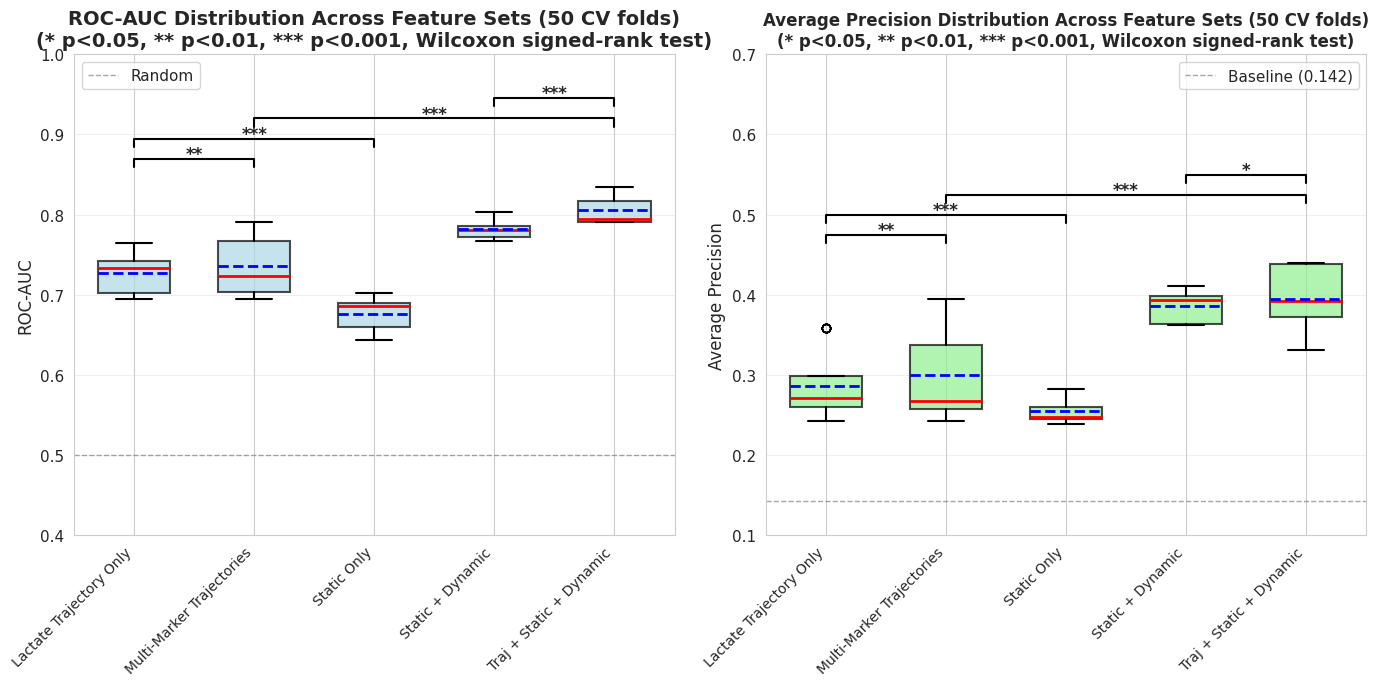

In [ ]:
# Boxplot visualization with statistical significance testing (using shared utilities)
# Define key pairwise comparisons
pairwise_comparisons = [
    (0, 1),  # Lactate Traj vs Multi-Marker Traj
    (0, 2),  # Lactate Traj vs Static Only
    (1, 4),  # Multi-Marker Traj vs Traj+Static+Dynamic
    (3, 4),  # Static+Dynamic vs Traj+Static+Dynamic
]

feature_names = list(comparison_results.keys())
n_folds_total = len(comparison_results[feature_names[0]]['roc_auc'])

# Use shared utility function for boxplots with significance testing
fig, (ax1, ax2) = plot_boxplots_with_stats(
    comparison_results=comparison_results,
    outcome_df=outcome_df,
    target_col='target_septic_shock',
    pairs_to_compare=pairwise_comparisons,
    n_folds_total=n_folds_total
)
plt.savefig('../../results/mimic/sepsis/model_comparison_boxplots_significance.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: model_comparison_boxplots_significance.png")
plt.show()

# Print detailed statistical comparisons using shared utility
print_statistical_comparisons(
    comparison_results=comparison_results,
    pairs_to_compare=pairwise_comparisons
)


✓ Saved: results/mimic/sepsis/model_comparison_curves.png


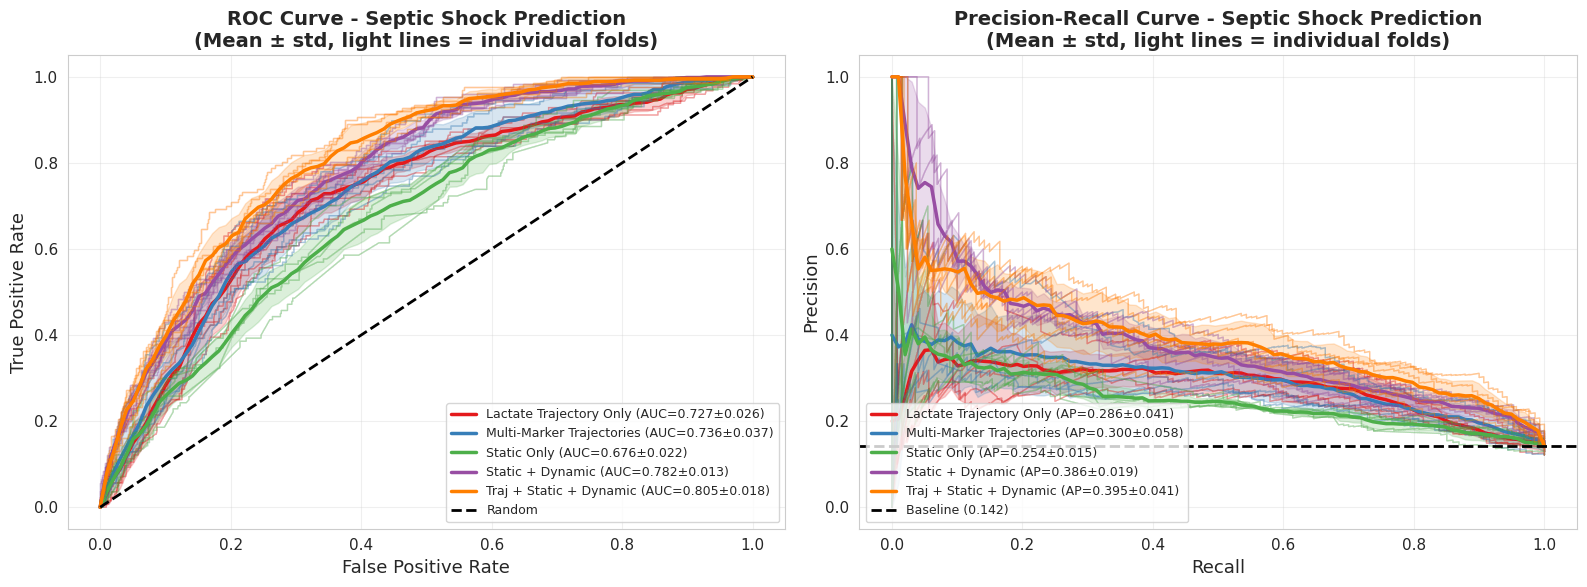

In [ ]:
# ROC & PR Curves - Using shared utility function
fig, (ax1, ax2) = plot_roc_pr_curves(
    comparison_results=comparison_results,
    outcome_df=outcome_df,
    target_col='target_septic_shock',
    color_scheme='tab10'
)

# Update titles for sepsis context
ax1.set_title('ROC Curves - Septic Shock Prediction', fontsize=14, fontweight='bold')
ax2.set_title('Precision-Recall Curves - Septic Shock Prediction', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../../results/mimic/sepsis/model_comparison_curves.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: model_comparison_curves.png")
plt.show()

# Summary and clinical interpretation
print(f"\n📊 Summary:")
print(f"    - Multi-marker trajectories capture organ dysfunction progression")
print(f"    - Comprehensive model includes perfusion, infection, coagulation, and organ function")
print(f"    - Enables timely intervention (fluids, antibiotics, vasopressors, organ support)")

In [77]:
best_model = max(comparison_results.items(), key=lambda x: np.mean(x[1]['roc_auc']))

print("\n✓ Multi-marker sepsis progression analysis complete!")
print(f"\n  Key Results:")
print(f"    - Dataset: {len(prediction_clean):,} prediction windows")
print(f"    - Patients: {groups.nunique():,} sepsis admissions")
print(f"    - Event rate: {y.mean():.1%}")
print(f"    - Best model: {best_model[0]} (AUC={np.mean(best_model[1]['roc_auc']):.3f})")
print(f"\n  Feature Engineering:")
print(f"    - Trajectory markers: Lactate + WBC + Platelets")
print(f"    - Vitals: HR, MAP, Temp, RR, SpO2")
print(f"    - Labs: Creatinine, Bilirubin, INR, pH, Bicarb")
print(f"    - Clinical flags: 9 SIRS/organ dysfunction indicators")
print(f"\n  Clinical Impact:")
print(f"    - Early detection of septic shock (48h ahead)")
print(f"    - Multi-marker trajectories capture organ dysfunction progression")
print(f"    - Comprehensive model includes perfusion, infection, coagulation, and organ function")
print(f"    - Enables timely intervention (fluids, antibiotics, vasopressors, organ support)")


✓ Multi-marker sepsis progression analysis complete!

  Key Results:
    - Dataset: 2,483 prediction windows
    - Patients: 690 sepsis admissions
    - Event rate: 38.8%
    - Best model: Traj + Static + Dynamic (AUC=0.625)

  Feature Engineering:
    - Trajectory markers: Lactate + WBC + Platelets
    - Vitals: HR, MAP, Temp, RR, SpO2
    - Labs: Creatinine, Bilirubin, INR, pH, Bicarb
    - Clinical flags: 9 SIRS/organ dysfunction indicators

  Clinical Impact:
    - Early detection of septic shock (48h ahead)
    - Multi-marker trajectories capture organ dysfunction progression
    - Comprehensive model includes perfusion, infection, coagulation, and organ function
    - Enables timely intervention (fluids, antibiotics, vasopressors, organ support)
